### aim: compare LA50 and LAH3 ecosystems

### date: 

In [40]:
%reset

Once deleted, variables cannot be recovered. Proceed (y/[n])?  y


In [41]:
# ================================
# IMPORTS
# ================================
import os
import glob
import pickle
import time
import warnings
from datetime import datetime
from importlib import reload

import numpy as np
import pandas as pd
import xarray as xr
import netCDF4 as nc
import seawater

import matplotlib.pyplot as plt
from matplotlib import font_manager, rcParams
import matplotlib.path as mpath

import cartopy as cp
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from cmocean import cm

import sys
sys.path.append('/gpfs/home/mep22dku/scratch/SOZONE/UTILS/')
import utils as ut
from importlib import reload


# Jupyter magic
%matplotlib inline

# Suppress warnings
warnings.filterwarnings('ignore')

# ================================
# FONT CONFIGURATION
# ================================
# Disable LaTeX (use mathtext with chosen font)
plt.rcParams['text.usetex'] = False

# Base font size
fs = 11

# Path to Gill Sans
gill_sans_path = "/gpfs/home/mep22dku/scratch/FONTS/gill-sans/GillSansMedium.otf"

# Try to load custom font
if os.path.exists(gill_sans_path):
    font_manager.fontManager.addfont(gill_sans_path)
    gill_font_name = font_manager.FontProperties(fname=gill_sans_path).get_name()
    chosen_font = gill_font_name
    print(f"✓ Using custom font: {gill_font_name}")
else:
    chosen_font = "DejaVu Sans"
    print("⚠️ Gill Sans not found, using fallback: DejaVu Sans")

# Apply font settings
rcParams.update({
    'font.size': fs,
    'font.family': chosen_font,
    'axes.titlesize': fs,
    'axes.labelsize': fs,
    'xtick.labelsize': fs,
    'ytick.labelsize': fs,
    'legend.fontsize': fs,
    'mathtext.fontset': 'custom',
    'mathtext.rm': chosen_font,
    'mathtext.it': chosen_font,
    'mathtext.bf': chosen_font,
})

✓ Using custom font: Gill Sans


In [42]:
mask = xr.open_dataset('/gpfs/home/mep22dku/scratch/SOZONE/UTILS/mesh_mask3pt6_nicedims.nc')


In [43]:
#kostelec - polsko
kostelec_6 = ['#C94B3C', '#E47A5C', '#A8B89C', '#6B9B7D', '#7FA4B8', '#4A3830']
kostelec_12 = ['#B23D32', '#C94B3C', '#E47A5C', '#D89B7A', '#E5C9A8', '#C8D4B8', '#A8B89C', '#6B9B7D', '#7FA4B8', '#5B7A8C', '#4A3830', '#2A1F1A']

#prachov - jezero 
prachovjezero_6 = ['#E85A2A', '#F4A63D', '#6B8C3E', '#5B9BAD', '#4A6B8A', '#6B3428']
prachovjezero_12 = ['#D84B28', '#E85A2A', '#F27435', '#F4A63D', '#D4B665', '#89A648', '#6B8C3E', '#4E7054', '#5B9BAD', '#4A6B8A', '#6B3428', '#3D2820']

# Tatry 
tatry_6 = ['#9B7850', '#D4C8A8', '#5B7F68', '#7BA6BC', '#A8BECF', '#3A4F3C']
tatry_12 = ['#7A5F40', '#9B7850', '#C4B090', '#E5D8B8', '#B8D090', '#8FAB80', '#5B7F68', '#5B7B7C', '#7BA6BC', '#A8BECF', '#3A4F3C', '#2B3A2E']
#cesky raj
ceskyraj_6 = ['#B8734E', '#D4A562', '#6B8BA8', '#4B6B8C', '#8B5B7A', '#3A2F28']
ceskyraj_12 = ['#A85C3C', '#B8734E', '#D49558', '#D4A562', '#E5C485', '#9CB68A', '#6B8B72', '#6B8BA8', '#4B6B8C', '#8B5B7A', '#5B3F4A', '#3A2F28']

## prachov - skaly
prachovskaly_6 = ['#B8844E', '#D4A865', '#6B8B5C', '#4B7B8C', '#2B5B8C', '#1B3F5C']
prachovskaly_12 = ['#9B6B3C', '#B8844E', '#C89B5A', '#D4A865', '#E5C68A', '#8BA872', '#6B8B5C', '#4B6B5A', '#5B8B9C', '#4B7B8C', '#2B5B8C', '#1B3F5C']

## jested lanovka
jested_6 = ['#D86B45', '#D4B870', '#8FAB7C', '#5B7B8C', '#6B8BAC', '#3A5B48']
jested_12 = ['#C85B3A', '#D86B45', '#E59B58', '#D4B870', '#E5D090', '#B8C88C', '#8FAB7C', '#6B8B78', '#5B7B8C', '#6B8BAC', '#4B6B5C', '#3A5B48']

## krkonose 
krkonose_6 = ['#E5A542', '#C4D858', '#6B8B5C', '#4B6B8C', '#7A9BAC', '#8B6B47']
krkonose_12 = ['#B87A3C', '#E5A542', '#F5C855', '#D4DB6A', '#C4D858', '#A8C850', '#6B8B5C', '#5B7B6C', '#4B6B8C', '#7A9BAC', '#8B6B47', '#5B4B38']

## dumbier
dumbier_6 = ['#D87845', '#E5C8A0', '#4B7BC2', '#6B9BD8', '#7AB8E5', '#1A2B3A']
dumbier_12 = ['#C86838', '#D87845', '#E59B68', '#E5C8A0', '#F5E8D0', '#A8C8E5', '#7AB8E5', '#6B9BD8', '#4B7BC2', '#3A5B8C', '#2A3B5C', '#1A2B3A']

## assorted snippets

#### netcdf

In [44]:
sav = False
if sav:
    savenam = 'test2.nc'
    data_vars = {'vomecrty':(['time_counter', 'depthv', 'y', 'x'], vomecrty.values,
    {'units': 'µatm',
    'long_name':'Surface ocean pCO2'}),
    }
    # define coordinates
    coords = {'time_counter': (['time_counter'], time_counter),
            'time_centered': (['time_centered'], time_centered),
    'nav_lat': (['y','x'], nav_lat),
    'nav_lon': (['y','x'], nav_lon),
    'depthv': (['depthv'], depthv)}
    # define global attributes
    attrs = {'made in':'SOZONE/MEDUSA/makeYearlyMEDUSAsubsetfiles.ipynb',
    'desc': 'yearly medusa files, saving only variables of interest'
    }
    ds = xr.Dataset(data_vars=data_vars,
    coords=coords,
    attrs=attrs)
    ds.to_netcdf(savenam)

#### tylist

In [45]:
def make_yearlist(yrst, yrend, dtype, tr, baseDir):
    yrs = np.arange(yrst,yrend+1,1)
    ylist = []
    for i in range(0,len(yrs)):
        ty = f'{baseDir}/{tr}/ORCA2_1m_{yrs[i]}*{dtype}*.nc'
        t2 = glob.glob(ty)
        #print(t2)
        ylist.append(t2[0])
    return ylist

#### notebook footer

In [46]:
def add_notebook_footer(fig, notebook_name, path_y_position=0.02):
    """
    Add notebook path as footer to figure with automatic spacing.
    
    Parameters:
    -----------
    fig : matplotlib figure object
    notebook_name : str
        Name of the notebook file (e.g., 'AMOCts.ipynb')
    path_y_position : float
        Y position for the footer text (default 0.02 = 2% from bottom)
        
    usage 
    bottom_margin = add_notebook_footer(fig, 'AMOCts.ipynb')
    plt.tight_layout(rect=[0, bottom_margin, 1, 0.96])    
    """
    notebook_path = os.path.abspath(os.getcwd())
    full_notebook_path = os.path.join(notebook_path, notebook_name)
    fig.text(0.5, path_y_position, f'Notebook: {full_notebook_path}', ha='center', 
             fontsize=10, style='italic', color='gray')
    
    # Return the bottom margin needed for tight_layout
    return path_y_position + 0.05  # Add buffer above text

## check AMOC strength 1950-1960, 2010-2019

In [47]:
AMOC_LAH3 = xr.open_dataset('/gpfs/home/mep22dku/scratch/AMOC-PLANKTOM/AMOC-LoP-202510/data/AMOC_TOM12_TJ_LAH3_1940-2024.nc')
AMOC_LA50 = xr.open_dataset('/gpfs/home/mep22dku/scratch/AMOC-PLANKTOM/AMOC-LoP-202510/data/AMOC_TOM12_TJ_LA50_1940-2024.nc')


In [48]:
ds = AMOC_LA50
amoc_subset = ds['AMOC'].sel(TIME=slice('1950-01-01', '1959-12-31'))
mean_value = amoc_subset.mean().values
print(mean_value)

ds = AMOC_LAH3
amoc_subset = ds['AMOC'].sel(TIME=slice('2010-01-01', '2019-12-31'))
mean_value = amoc_subset.mean().values
print(mean_value)

16.039548818270365
13.183202656110128


## EXTRACT: get mean clims for both datasets, pre and post hosing
    this is in extract-clim.py

## EXTRACT: get LoP, depth-integrated phyto, surface nutrients

    getting LoP is in extract-LoP.py
    depth integrated things are in python extract-depthint.py
    surface means are in extract-surfmean.py -- needs to be rerun with LoP running. 

## EXTRACT: provincial avg!

    -rw-r--r-- 1 mep22dku greenocean 15864548 Dec  8 21:36 TOM12_TJ_LAH3_1964_dint_ptrc.nc
    -rw-r--r-- 1 mep22dku greenocean 18468615 Dec  8 21:36 TOM12_TJ_LAH3_1964_dint_diad.nc
    -rw-r--r-- 1 mep22dku greenocean 10656620 Dec  8 21:57 TOM12_TJ_LAH3_1964_surf100_ptrc.nc
    -rw-r--r-- 1 mep22dku greenocean 10656620 Dec  8 21:57 TOM12_TJ_LAH3_1964_surf200_ptrc.nc
    -rw-r--r-- 1 mep22dku greenocean 15864070 Dec  8 23:04 TOM12_TJ_LAH3_1964_surf100_LoP.nc
    -rw-r--r-- 1 mep22dku greenocean 15864070 Dec  8 23:04 TOM12_TJ_LAH3_1964_surf200_LoP.nc
    
    these are in prov-avg.py
    
    also need from diad - PPINT, Cflx
    from grid_T - somxl, sos, tos, 

## in LoP, zeros to nans

In [49]:
import xarray as xr
import numpy as np
from pathlib import Path

def convert_zeros_to_nan(input_file, output_file=None):
    """
    Convert zeros to NaNs in a NetCDF file.
    
    Args:
        input_file: Path to input .nc file
        output_file: Path to output file. If None, saves as input_file + '_converted.nc'
    
    Example:
        convert_zeros_to_nan("./data/TOM12_TJ_LA50_1944_surf200_LoP.nc")
        convert_zeros_to_nan("./data/TOM12_TJ_LA50_1944_surf200_LoP.nc", 
                           "./data/TOM12_TJ_LA50_1944_surf200_LoP_clean.nc")
    """
    # Default output name if not specified
    if output_file is None:
        path = Path(input_file)
        output_file = path.parent / f"{path.stem}_nn{path.suffix}"
    
    # Open the NetCDF file
    ds = xr.open_dataset(input_file)
    
    # Convert zeros to NaNs for all variables
    for var in ds.data_vars:
        data = ds[var].values
        # Replace zeros with NaN (handles both float and int arrays)
        data = data.astype(float)  # Convert to float to allow NaN
        data[data == 0] = np.nan
        ds[var].values = data
    
    # Save to new file
    ds.to_netcdf(output_file)
    ds.close()
    
    print(f"Saved: {input_file} -> {output_file}")
    
ex = False
if ex:
    mods = ['LA50','LAH3']
    for mod in mods:
        for yr in range(1940,2024):

            tnam = f'./data/TOM12_TJ_{mod}_{yr}_surf200_LoP.nc'
            convert_zeros_to_nan(tnam)

## ## difference plots! 

#### universal difference plot maker

In [50]:
import matplotlib.pyplot as plt

def plot_var_comparisons(
    ds1,
    ds2,
    var_names,
    var_titles,
    var_clims,
    x_min=100, x_max=160,
    y_min=70, y_max=140,
    ds1nam = 'Dataset 1',
    ds2nam = 'Datset 2',
    time_dim='time_counter',
    save = False,
    savenam = 'null.png',
    cmap1 = 'Spectral_r', 
    cmap2 = 'Spectral_r',
    cmap3 = 'Spectral_r'
):
    """
    Plot comparisons between variables in two xarray datasets.
    
    Parameters
    ----------
    ds1, ds2 : xarray.Dataset
        Datasets containing the variables.
    var_names : list of str
        Variable names to plot.
    var_titles : list of str
        Titles for each variable.
    var_clims : dict
        Dict of {var_name: (vmin, vmax)}.
    x_min, x_max, y_min, y_max : float
        Spatial boundaries for x/y limits.
    time_dim : str
        Name of the time dimension to average over.
    """
    
    # Precompute means and masks
    data1, data2, diff = {}, {}, {}
    
    for var in var_names:
        var1 = ds1[var].mean(dim=time_dim).where(ds1[var].mean(dim=time_dim) != 0)
        var2 = ds2[var].mean(dim=time_dim).where(ds2[var].mean(dim=time_dim) != 0)
        
        data1[var] = var1
        data2[var] = var2
        diff[var] = var1 - var2

    # Figure: rows = number of variables, cols = 3 comparisons
    n_vars = len(var_names)
    fact = 0.8
    fig, axes = plt.subplots(n_vars, 3, figsize=(16 * fact, 4 * n_vars * fact))

    if n_vars == 1:
        axes = axes.reshape(1, 3)

    for i, var in enumerate(var_names):
        clim = var_clims[var]
        title = var_titles[i]
        if i == 0: tcmap = cmap1
        if i == 1: tcmap = cmap2
        if i == 2: tcmap = cmap3

        # Dataset 1
        data1[var].plot(ax=axes[i, 0], cmap=tcmap, vmin=clim[0], vmax=clim[1])
        axes[i, 0].set_title(f'{title} - {ds1nam}')

        # Dataset 2
        data2[var].plot(ax=axes[i, 1], cmap=tcmap, vmin=clim[0], vmax=clim[1])
        axes[i, 1].set_title(f'{title} - {ds2nam}')

        # Difference
        diff[var].plot(ax=axes[i, 2], cmap='RdBu_r')
        axes[i, 2].set_title(f'{title} - Difference ({ds1nam} - {ds2nam})')

    # Apply limits
    for row in axes:
        for ax in row:
            ax.set_xlim(x_min, x_max)
            ax.set_ylim(y_min, y_max)

    bottom_margin = add_notebook_footer(fig, 'hosed-world-ecosystem.ipynb')
    plt.tight_layout(rect=[0, bottom_margin, 1, 0.96])   
    
    if save:
        fig.savefig(savenam, dpi = 300)
    plt.show()


## ecosystem - get dominant phyto

In [51]:
ex = False; 
if ex: 
    import helpfxn as hf
    reload(hf)
    tdir = './data'; sdir = tdir
    tfil = 'TJ_LAH3_ptrc_2010-2019.nc'
    hf.integrate_and_identify_dominant_phytoplankton(tdir, tfil, sdir, species_order=None, temporal_res = 'all')
    tfil = 'TJ_LA50_ptrc_2010-2019.nc'
    hf.integrate_and_identify_dominant_phytoplankton(tdir, tfil, sdir, species_order=None, temporal_res = 'all')

In [52]:
LAH3_phy = xr.open_dataset('./data/TJ_LAH3_depthint_phyto_2010-2019.nc')
LA50_phy = xr.open_dataset('./data/TJ_LA50_depthint_phyto_2010-2019.nc')


## comparison plot of ecosystem// dominant species

Figure saved to: ./plts/TOM12_TJ_LA50-dominant_species-ATL.png


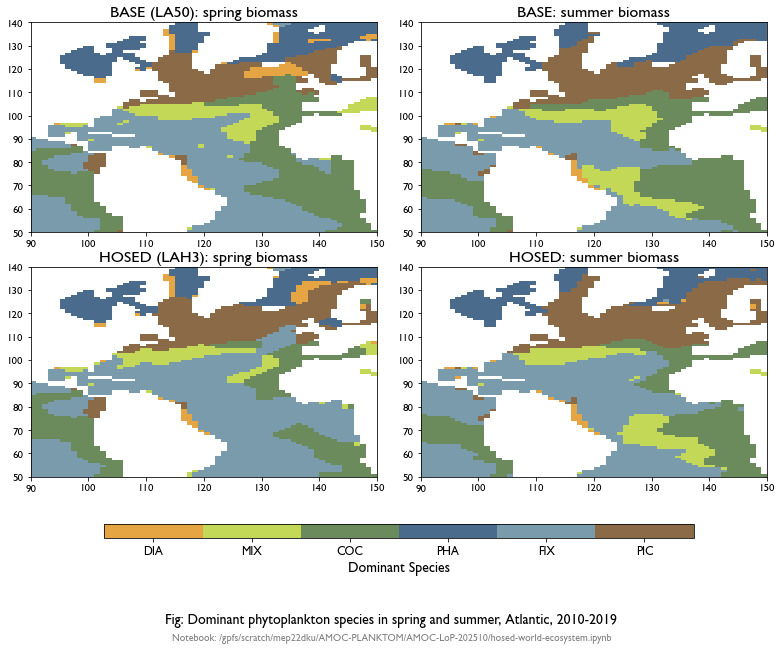

In [53]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import numpy as np
import os

tmesh = xr.open_dataset('/gpfs/home/mep22dku/scratch/AMOC-PLANKTOM/data/meshmask_with_Atl.nc')

# ============ SETTINGS ============
# Set axis ranges here (zoom control)
X_MIN = 90  # Set to None for full range, or specify value (e.g., 0)
X_MAX = 150  # Set to None for full range, or specify value (e.g., 100)
Y_MIN = 50  # Set to None for full range, or specify value (e.g., 0)
Y_MAX = 140  # Set to None for full range, or specify value (e.g., 100)

# Figure description
FIG_DESCRIPTION = "Fig: Dominant phytoplankton species in spring and summer, Atlantic, 2010-2019"
SHOW_NOTEBOOK_PATH = True  # Set to False to hide notebook path
NOTEBOOK_NAME = "hosed-world-ecosystem.ipynb"  # Manually set your notebook name here
OUTPUT_NAM = 'TOM12_TJ_LA50-dominant_species-ATL.png'
# Output directory
OUTPUT_DIR = "./plts"
save = True
colors = krkonose_6

# ===== LAYOUT PARAMETERS (adjust these!) =====
FIGURE_WIDTH = 11          # Width of figure in inches
FIGURE_HEIGHT = 9         # Height of figure in inches (increase to reduce vertical squishing)
TITLE_FONTSIZE = 16        # Font size for subplot titles
COLORBAR_LABEL_FONTSIZE = 14   # Font size for colorbar label
COLORBAR_TICK_FONTSIZE = 12    # Font size for colorbar tick labels
DESCRIPTION_FONTSIZE = 14      # Font size for figure description
PATH_FONTSIZE = 10             # Font size for notebook path
DESCRIPTION_Y_POSITION = 0.03  # Vertical position of description (0=bottom, 1=top)
PATH_Y_POSITION = 0.004        # Vertical position of path (below description)
TIGHT_LAYOUT_BOTTOM = 0.002     # Bottom margin for tight_layout (increase to add space for description)
COLORBAR_PAD = 0.08            # Space between plots and colorbar
# ============================================
# ==================================

# Get current directory path
notebook_path = os.path.abspath(os.getcwd())

# Combine path and name
full_notebook_path = os.path.join(notebook_path, NOTEBOOK_NAME)

# Create output directory if it doesn't exist
os.makedirs(OUTPUT_DIR, exist_ok=True)

# List of your 4 xarrays
#datasets = [tptrc_spring_int, tptrc_summer_int, tdiad_spring_int, tdiad_summer_int]

datasets = [LA50_phy.dominant_species_seasonal.sel(season = 2),
            LA50_phy.dominant_species_seasonal.sel(season = 3),
            LAH3_phy.dominant_species_seasonal.sel(season = 2),
            LAH3_phy.dominant_species_seasonal.sel(season = 3)]



titles = ['BASE (LA50): spring biomass', 'BASE: summer biomass', 'HOSED (LAH3): spring biomass', 'HOSED: summer biomass']

# Apply mask
tmask = tmesh.tmaskutil.squeeze('t', drop=True) if 't' in tmesh.tmaskutil.dims else tmesh.tmaskutil

# Custom colors for the 6 species
cmap = ListedColormap(colors)
bounds = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5]
norm = BoundaryNorm(bounds, cmap.N)

fig, axes = plt.subplots(2, 2, figsize=(FIGURE_WIDTH, FIGURE_HEIGHT))
axes = axes.flatten()

for i, (ax, data, title) in enumerate(zip(axes, datasets, titles)):
    masked_dominant = data.where(tmask == 1)
    im = ax.pcolormesh(masked_dominant, cmap=cmap, norm=norm)
    ax.set_title(title, fontsize=TITLE_FONTSIZE)
    
    # Remove axis ticks
#     ax.set_xticks([])
#     ax.set_yticks([])
    
    # Set axis ranges if specified
    if X_MIN is not None or X_MAX is not None:
        ax.set_xlim(X_MIN, X_MAX)
    if Y_MIN is not None or Y_MAX is not None:
        ax.set_ylim(Y_MIN, Y_MAX)

# Add shared colorbar with more padding and bigger font
plt.tight_layout(rect=[0, TIGHT_LAYOUT_BOTTOM, 1, 1])
cbar = fig.colorbar(im, ax=axes, orientation='horizontal', pad=COLORBAR_PAD, aspect=40, shrink=0.8)
cbar.set_ticks([1, 2, 3, 4, 5, 6])
cbar.set_ticklabels(['DIA', 'MIX', 'COC', 'PHA', 'FIX', 'PIC'], fontsize=COLORBAR_TICK_FONTSIZE)
cbar.set_label('Dominant Species', fontsize=COLORBAR_LABEL_FONTSIZE)

# Add figure description at the bottom
fig.text(0.5, DESCRIPTION_Y_POSITION, FIG_DESCRIPTION, ha='center', fontsize=DESCRIPTION_FONTSIZE, style='italic')

# Add notebook path if enabled
if SHOW_NOTEBOOK_PATH:
    fig.text(0.5, PATH_Y_POSITION, f'Notebook: {full_notebook_path}', ha='center', fontsize=PATH_FONTSIZE, 
             style='italic', color='gray')

# Save figure
output_path = os.path.join(OUTPUT_DIR, OUTPUT_NAM)
if save:
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"Figure saved to: {output_path}")

plt.show()


### difference plot: climatological T, S, mld

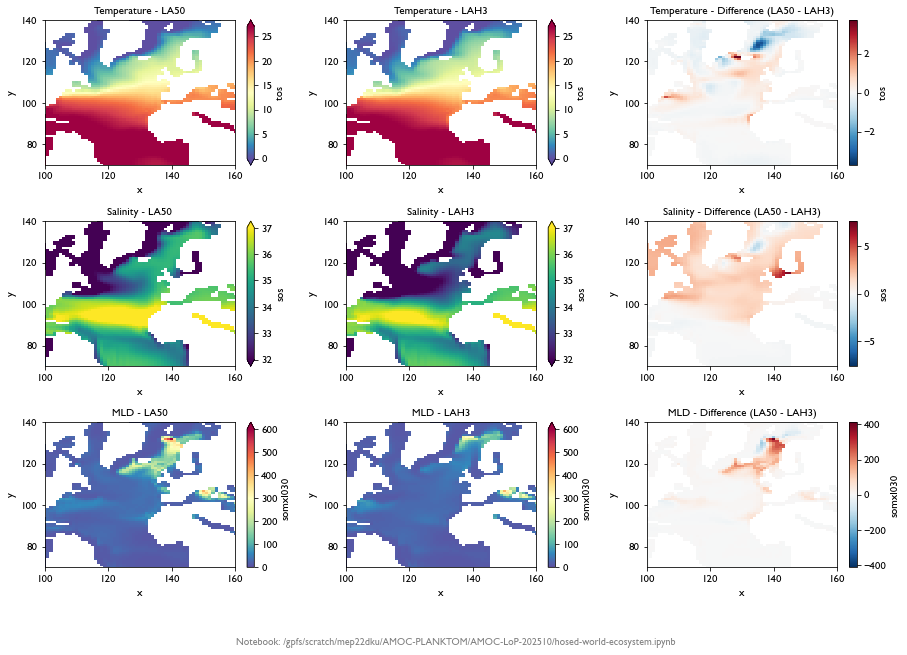

In [54]:
var_names = ['tos', 'sos', 'somxl030']
var_titles = ['Temperature', 'Salinity', 'MLD']
var_clims = {
    'tos': (0, 27),
    'sos': (32, 37),
    'somxl030': (0, 600)
}

ds1 = xr.open_dataset('./data/TJ_LA50_grid_T_2010-2019.nc')
ds2 = xr.open_dataset('./data/TJ_LAH3_grid_T_2010-2019.nc')

plot_var_comparisons(
    ds1,
    ds2,
    var_names,
    var_titles,
    var_clims,
    ds1nam = 'LA50',
    ds2nam = 'LAH3',
    x_min=100, x_max=160,
    y_min=70, y_max=140,
    time_dim='month',
    save = True,
    savenam = './plts/Hosedworld-physics.jpg',
    cmap1 = 'Spectral_r', 
    cmap2 = 'viridis',
    cmap3 = 'Spectral_r'
)

### difference plot: diad

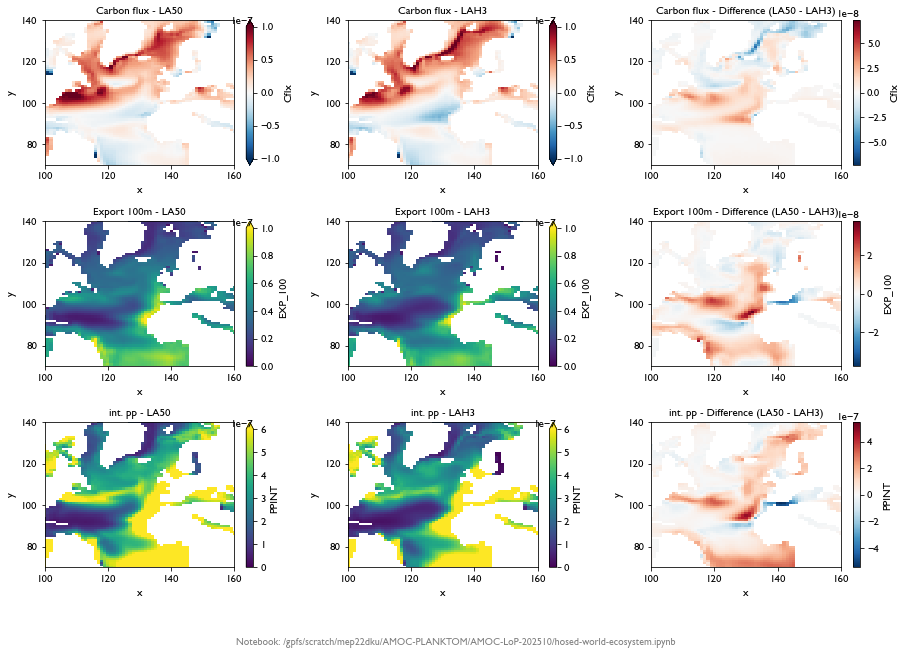

In [55]:
ds1 = xr.open_dataset('./data/TJ_LA50_diad_2010-2019.nc')
ds2 = xr.open_dataset('./data/TJ_LAH3_diad_2010-2019.nc')

ds1['EXP_100'] = (ds1['EXP'].isel(deptht = 9) + ds1['EXP'].isel(deptht = 10))/2
ds2['EXP_100'] = (ds2['EXP'].isel(deptht = 9) + ds2['EXP'].isel(deptht = 10))/2

var_names = ['Cflx', 'EXP_100', 'PPINT']
var_titles = ['Carbon flux', 'Export 100m', 'int. pp']
var_clims = {
    'Cflx': (-1e-7, 1e-7),
    'EXP_100': (0, 1e-7),
    'PPINT': (0, 6e-7)
}

plot_var_comparisons(
    ds1,
    ds2,
    var_names,
    var_titles,
    var_clims,
    ds1nam = 'LA50',
    ds2nam = 'LAH3',
    x_min=100, x_max=160,
    y_min=70, y_max=140,
    time_dim='month',
    save = True,
    savenam = './plts/Hosedworld-diad.jpg',
    cmap1 = 'RdBu_r', 
    cmap2 = 'viridis',
    cmap3 = 'viridis'
)

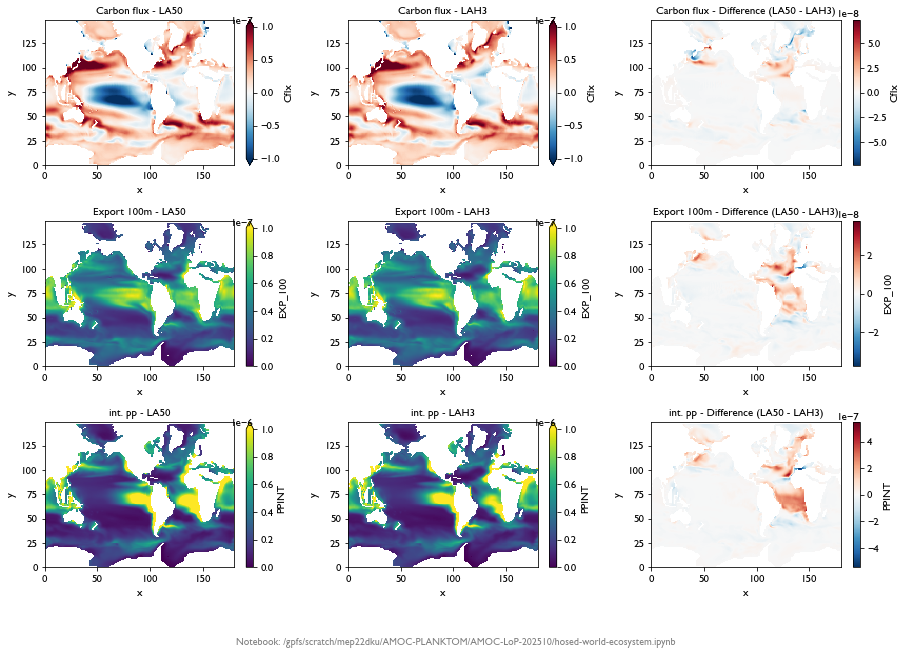

In [56]:
ds1 = xr.open_dataset('./data/TJ_LA50_diad_2010-2019.nc')
ds2 = xr.open_dataset('./data/TJ_LAH3_diad_2010-2019.nc')

ds1['EXP_100'] = (ds1['EXP'].isel(deptht = 9) + ds1['EXP'].isel(deptht = 10))/2
ds2['EXP_100'] = (ds2['EXP'].isel(deptht = 9) + ds2['EXP'].isel(deptht = 10))/2

var_names = ['Cflx', 'EXP_100', 'PPINT']
var_titles = ['Carbon flux', 'Export 100m', 'int. pp']
var_clims = {
    'Cflx': (-1e-7, 1e-7),
    'EXP_100': (0, 1e-7),
    'PPINT': (0, 1e-6)
}

plot_var_comparisons(
    ds1,
    ds2,
    var_names,
    var_titles,
    var_clims,
    ds1nam = 'LA50',
    ds2nam = 'LAH3',
    x_min=0, x_max=180,
    y_min=0, y_max=149,
    time_dim='month',
    save = True,
    savenam = './plts/Hosedworld-diad-fullglobe.jpg',
    cmap1 = 'RdBu_r', 
    cmap2 = 'viridis',
    cmap3 = 'viridis'
)

# difference bargraphs

    TOM12_TJ_LAH3_1940_dint_ptrc_PROV.nc
    TOM12_TJ_LAH3_1940_dint_diad_PROV.nc
    TOM12_TJ_LAH3_1940_surf100_ptrc_PROV.nc
    TOM12_TJ_LAH3_1940_surf200_ptrc_PROV.nc
    TOM12_TJ_LAH3_1940_surf200_LoP_PROV.nc
    TOM12_TJ_LAH3_1940_surf100_LoP_PROV.nc
    TOM12_TJ_LAH3_1940_diad2d_PROV.nc
    TOM12_TJ_LAH3_1940_grid_T2d_PROV.nc

    TOM12_TJ_LA50_1940_dint_ptrc_PROV.nc
    TOM12_TJ_LA50_1940_dint_diad_PROV.nc
    TOM12_TJ_LA50_1940_surf100_ptrc_PROV.nc
    TOM12_TJ_LA50_1940_surf200_ptrc_PROV.nc
    TOM12_TJ_LA50_1940_surf200_LoP_PROV.nc
    TOM12_TJ_LA50_1940_surf100_LoP_PROV.nc
    TOM12_TJ_LA50_1940_diad2d_PROV.nc
    TOM12_TJ_LA50_1940_grid_T2d_PROV.nc

# get datasets for provincial averages

In [57]:
def make_plist(yrst, yrend, dtype, mod):
    yrs = np.arange(yrst, yrend+1, 1)
    ylist = []
    for i in range(0, len(yrs)):
        ty = f'./data/{mod}_{yrs[i]}_{dtype}_PROV.nc'
        t2 = glob.glob(ty)
        ylist.append(t2[0])
    return ylist

y1 = 2010
y2 = 2019

# Define the models and data types
models = ['TOM12_TJ_LAH3', 'TOM12_TJ_LA50']
dtypes = ['dint_ptrc', 'dint_diad', 'surf100_ptrc',  'diad2d', 'grid_T2d',
         'surf100_LoP','surf100_light',\
         ]
# 'surf200_ptrc','surf200_LoP','surf200_light'

#'surf200_LoP', 'surf100_LoP',

# Create a dictionary to store all datasets
datasets = {}

# Load and average all datasets
for mod in models:
    for dtype in dtypes:
        
        key = f'{mod}_{dtype}'
        print(key)
        ds = xr.open_mfdataset(make_plist(y1, y2, dtype, mod))
        datasets[key] = ds.mean(dim='time_counter')

LAH3_dint_ptrc = datasets['TOM12_TJ_LAH3_dint_ptrc']
LAH3_dint_diad = datasets['TOM12_TJ_LAH3_dint_diad']
LAH3_surf100_ptrc = datasets['TOM12_TJ_LAH3_surf100_ptrc']
#LAH3_surf200_ptrc = datasets['TOM12_TJ_LAH3_surf200_ptrc']
#LAH3_surf200_LoP = datasets['TOM12_TJ_LAH3_surf200_LoP']
LAH3_surf100_LoP = datasets['TOM12_TJ_LAH3_surf100_LoP']
LAH3_diad2d = datasets['TOM12_TJ_LAH3_diad2d']
LAH3_grid_T2d = datasets['TOM12_TJ_LAH3_grid_T2d']
#LAH3_surf200_light = datasets['TOM12_TJ_LAH3_surf200_light']
LAH3_surf100_light = datasets['TOM12_TJ_LAH3_surf100_light']


LA50_dint_ptrc = datasets['TOM12_TJ_LA50_dint_ptrc']
LA50_dint_diad = datasets['TOM12_TJ_LA50_dint_diad']
LA50_surf100_ptrc = datasets['TOM12_TJ_LA50_surf100_ptrc']
#LA50_surf200_ptrc = datasets['TOM12_TJ_LA50_surf200_ptrc']
#LA50_surf200_LoP = datasets['TOM12_TJ_LA50_surf200_LoP']
LA50_surf100_LoP = datasets['TOM12_TJ_LA50_surf100_LoP']
LA50_diad2d = datasets['TOM12_TJ_LA50_diad2d']
LA50_grid_T2d = datasets['TOM12_TJ_LA50_grid_T2d']
#LA50_surf200_light = datasets['TOM12_TJ_LA50_surf200_light']
LA50_surf100_light = datasets['TOM12_TJ_LA50_surf100_light']


TOM12_TJ_LAH3_dint_ptrc
TOM12_TJ_LAH3_dint_diad
TOM12_TJ_LAH3_surf100_ptrc
TOM12_TJ_LAH3_diad2d
TOM12_TJ_LAH3_grid_T2d
TOM12_TJ_LAH3_surf100_LoP
TOM12_TJ_LAH3_surf100_light
TOM12_TJ_LA50_dint_ptrc
TOM12_TJ_LA50_dint_diad
TOM12_TJ_LA50_surf100_ptrc
TOM12_TJ_LA50_diad2d
TOM12_TJ_LA50_grid_T2d
TOM12_TJ_LA50_surf100_LoP
TOM12_TJ_LA50_surf100_light


In [58]:
import matplotlib.pyplot as plt
import numpy as np

def compare_datasets_by_province(ds1, ds2, variables, ds1_name='DS1', ds2_name='DS2', 
                                  units=None, color1='steelblue', color2='coral', fact = 0.9,
                                savestr = None):
    """
    Compare mean values across provinces for multiple variables between two datasets.
    
    Parameters:
    -----------
    ds1, ds2 : xarray Dataset
        The two datasets to compare
    variables : list
        List of variable names to plot
    ds1_name, ds2_name : str
        Names for the datasets (for legend/labeling)
    units : dict or list
        Units for each variable. Can be dict mapping var names to units,
        or list of units in same order as variables
    color1, color2 : str
        Colors for the two datasets
    """
    n_vars = len(variables)
    fig, axes = plt.subplots(n_vars, 1, figsize=(8*fact, 4*n_vars*fact))
    
    # Handle single variable case (axes won't be an array)
    if n_vars == 1:
        axes = [axes]
    
    # Convert units to dict if it's a list
    if isinstance(units, list):
        units = {var: u for var, u in zip(variables, units)}
    elif units is None:
        units = {}
    
    provinces = ['ATL', 'NAH', 'NAM', 'NAL', 'NAT']
    x = np.arange(len(provinces))
    width = 0.35
    
    for idx, var in enumerate(variables):
        ax = axes[idx]
        
        # Calculate mean values for each province
        vals1 = [ds1[var].sel(province=prov).mean().values for prov in provinces]
        vals2 = [ds2[var].sel(province=prov).mean().values for prov in provinces]
        
        # Create bars
        ax.bar(x - width/2, vals1, width, label=ds1_name, color=color1, alpha=0.8)
        ax.bar(x + width/2, vals2, width, label=ds2_name, color=color2, alpha=0.8)
        
        ax.set_xlabel('Province')
        unit_str = f" ({units[var]})" if var in units else ""
        ax.set_ylabel(f'Mean Value{unit_str}')
        ax.set_title(var)
        ax.set_xticks(x)
        ax.set_xticklabels(provinces)
        ax.grid(axis='y', alpha=0.3)
        
        # Set y-axis limits to be near min/max
        all_vals = vals1 + vals2
        y_min, y_max = min(all_vals), max(all_vals)
        y_range = y_max - y_min
        ax.set_ylim(y_min - 0.1*y_range, y_max + 0.1*y_range)
        
        # Only add legend to first subplot
        if idx == 0:
            ax.legend()
    
    plt.tight_layout()
    if savestr is not None:
        
        fig.savefig(savestr, dpi = 300)
        
    plt.show()


## assemblage

In [59]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

def compare_stacked_by_province(ds1, ds2, variables, ds1_name='DS1', ds2_name='DS2', 
                                 colors=None, figsize=None, units=None, save_path=None):
    """
    Create stacked bar charts comparing two datasets, with subplots for each province.
    Variables are stacked in bars, colored from a colormap.
    
    Parameters:
    -----------
    ds1, ds2 : xarray Dataset
        The two datasets to compare
    variables : list
        List of variable names to stack
    ds1_name, ds2_name : str
        Names for the datasets
    colors : list
        List of colors for each variable (in order)
    figsize : tuple
        Figure size as (width, height). Default is (4*n_provinces, 6)
    units : str
        Units for the y-axis (e.g., 'm', 'kg/m³')
    save_path : str
        Path to save the figure (e.g., 'plot.png'). If None, figure is not saved
    """
    provinces = ['ATL', 'NAH', 'NAM', 'NAL', 'NAT']
    n_provinces = len(provinces)
    
    fig, axes = plt.subplots(1, n_provinces, figsize=figsize or (4*n_provinces, 6), sharey=True)
    
    # Handle single province case
    if not isinstance(axes, np.ndarray):
        axes = [axes]
    
    # Use provided colors or default
    if colors is None:
        colors = plt.cm.Set3(np.linspace(0, 1, len(variables)))
    
    x = np.array([0, 1])  # Positions for ds1 and ds2
    width = 0.6
    
    for prov_idx, prov in enumerate(provinces):
        ax = axes[prov_idx]
        
        # Calculate mean values for each variable in this province
        vals1 = [ds1[var].sel(province=prov).mean().values for var in variables]
        vals2 = [ds2[var].sel(province=prov).mean().values for var in variables]
        
        # Create stacked bars
        bottom1 = 0
        bottom2 = 0
        
        for var_idx, var in enumerate(variables):
            ax.bar(x[0] - width/2, vals1[var_idx], width, bottom=bottom1, 
                   color=colors[var_idx], label=var if prov_idx == 0 else '', alpha=0.8)
            ax.bar(x[1] + width/2, vals2[var_idx], width, bottom=bottom2, 
                   color=colors[var_idx], alpha=0.8)
            
            bottom1 += vals1[var_idx]
            bottom2 += vals2[var_idx]
        
        ylabel = 'Mean Value'
        if units:
            ylabel += f' ({units})'
        ax.set_ylabel(ylabel)
        ax.set_title(f'Province: {prov}')
        ax.set_xticks(x)
        ax.set_xticklabels([ds1_name, ds2_name])
        ax.grid(axis='y', alpha=0.3)
    
    # Add legend to the right of the last plot
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.02, 0.5), ncol=1)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to {save_path}")
    
    plt.show()

# Example usage:
# compare_stacked_by_province(LAH3_grid_T2d, LA50_grid_T2d,
#                             variables=['sossheig', 'somxl010', 'another_var'],
#                             ds1_name='LAH3', ds2_name='LA50',
#                             colors=['red', 'blue', 'green'],
#                             units='m',
#                             save_path='stacked_comparison.png')

Figure saved to ./plts/BAR-phyto.jpg


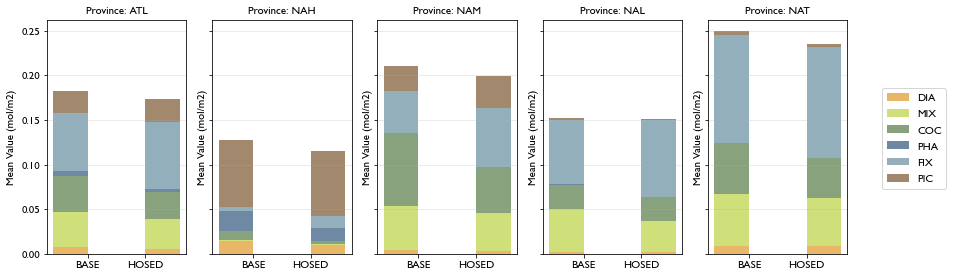

Figure saved to ./plts/BAR-ppt.jpg


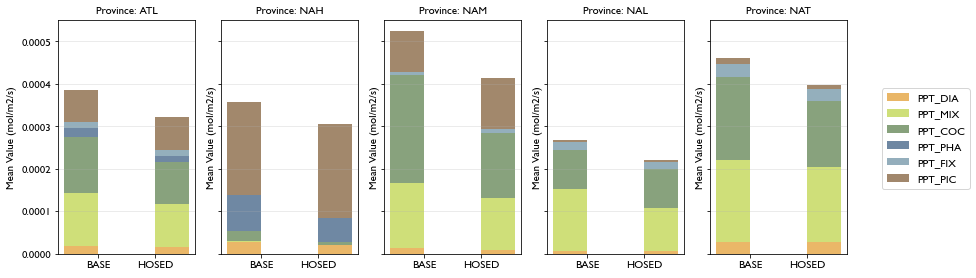

In [60]:
LAH3_dint_ptrc

compare_stacked_by_province(LA50_dint_ptrc, LAH3_dint_ptrc, ['DIA','MIX','COC','PHA','FIX','PIC'],\
                            ds1_name='BASE', ds2_name='HOSED', 
                                 colors=krkonose_6, units = 'mol/m2', figsize=(12,4),
                           save_path = './plts/BAR-phyto.jpg')

compare_stacked_by_province(LA50_dint_diad, LAH3_dint_diad, 
                            ['PPT_DIA','PPT_MIX','PPT_COC','PPT_PHA','PPT_FIX','PPT_PIC'],\
                            ds1_name='BASE', ds2_name='HOSED', 
                                 colors=krkonose_6, units = 'mol/m2/s', figsize=(12,4),
                           save_path = './plts/BAR-ppt.jpg')

## physics

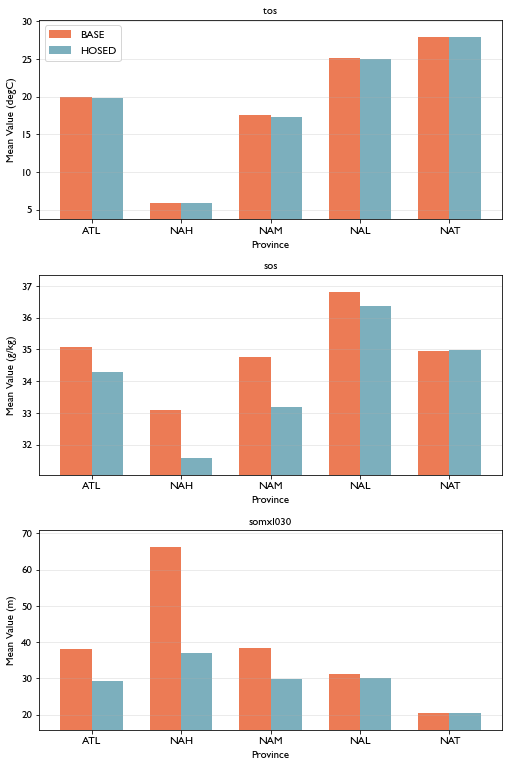

In [61]:
colormap = prachovjezero_6
c1 = prachovjezero_6[0]; c2 = prachovjezero_6[3]
compare_datasets_by_province(LA50_grid_T2d, LAH3_grid_T2d, ['tos','sos','somxl030'],'BASE','HOSED',\
                            units={'tos': 'degC', 'sos': 'g/kg', 'somxl030': 'm'},\
                            color1=c1, color2 = c2, savestr = './plts/BAR-phys.jpg')

## nutrients

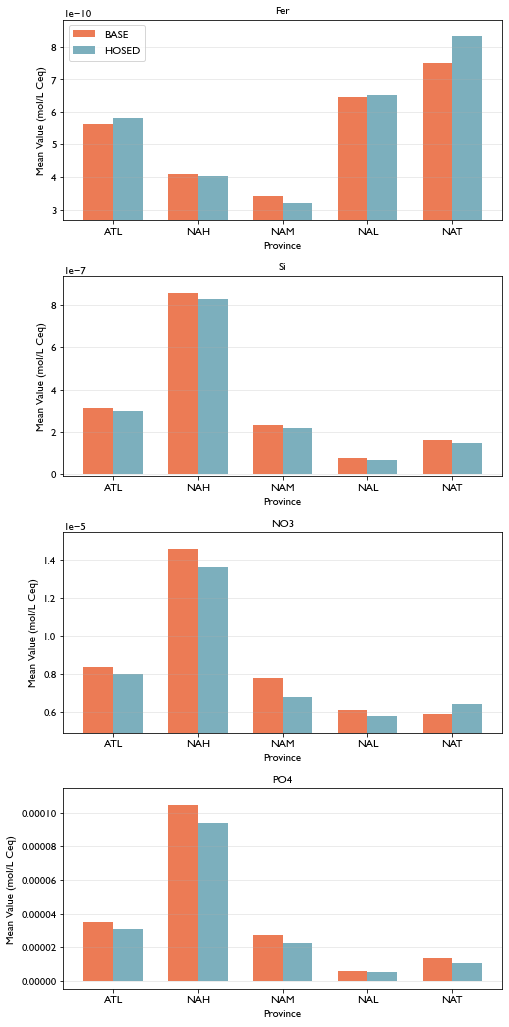

In [62]:
colormap = prachovjezero_6
c1 = prachovjezero_6[0]; c2 = prachovjezero_6[3]
compare_datasets_by_province(LA50_surf100_ptrc, LAH3_surf100_ptrc, ['Fer','Si','NO3','PO4'],\
                             'BASE','HOSED',\
                            units={'Fer': 'mol/L Ceq','Si': 'mol/L Ceq','NO3': 'mol/L Ceq','PO4': 'mol/L Ceq'},\
                            color1=c1, color2 = c2, savestr = './plts/BAR-nut-100.jpg')

# compare_datasets_by_province(LA50_surf200_ptrc, LAH3_surf200_ptrc, ['Fer','Si','NO3','PO4'],\
#                              'BASE','HOSED',\
#                             units={'Fer': 'mol/L Ceq','Si': 'mol/L Ceq','NO3': 'mol/L Ceq','PO4': 'mol/L Ceq'},\
#                             color1=c1, color2 = c2, savestr = './plts/BAR-nut-200.jpg')

# comparison summary plot

            dint_ptrc
            dint_diad
            surf100_ptrc
            surf200_ptrc
            surf100_LoP
            surf200_LoP
            surf100_light
            surf200_light
            diad2d
            grid_T2d

In [63]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def compare_runs(datasets, base_run='LA50', diff_run='LAH3', 
                 file_patterns=None, pattern_descriptions=None):
    """
    Compare two model runs and calculate percent differences for each variable and province.
    
    Parameters:
    -----------
    datasets : dict
        Dictionary of xarray datasets (from zarr or similar)
    base_run : str
        Base run name (e.g., 'LA50')
    diff_run : str
        Difference run name (e.g., 'LAH3')
    file_patterns : list
        List of file patterns to compare, e.g., 
        ['dint_ptrc', 'dint_diad', 'surf100_ptrc', ...]
    pattern_descriptions : dict
        Optional descriptions for each pattern, e.g.,
        {'dint_diad': 'carbon flux statistics', 'dint_ptrc': 'tracer diagnostics'}
    
    Returns:
    --------
    pd.DataFrame
        DataFrame with percent differences, indexed by (variable, province)
    """
    
    if file_patterns is None:
        file_patterns = [
            'dint_ptrc', 'dint_diad', 'surf100_ptrc', 'surf200_ptrc',
            'surf200_LoP', 'surf100_LoP', 'surf200_light', 'surf100_light','diad2d', 'grid_T2d'
        ]
    
    if pattern_descriptions is None:
        pattern_descriptions = {}
    
    results = []
    
    for pattern in file_patterns:
        base_key = f'TOM12_TJ_{base_run}_{pattern}'
        diff_key = f'TOM12_TJ_{diff_run}_{pattern}'
        
        if base_key not in datasets or diff_key not in datasets:
            print(f'Warning: Missing datasets for pattern {pattern}')
            continue
        
        base_ds = datasets[base_key]
        diff_ds = datasets[diff_key]
        print(f'Processing {pattern}')
        
        # Get province names from dataset
        province_names = None
        if 'province' in base_ds.dims:
            # If province is a coordinate
            if 'province' in base_ds.coords:
                province_names = base_ds['province'].values.tolist()
        elif 'PROV' in base_ds.dims:
            # If PROV is a coordinate
            if 'PROV' in base_ds.coords:
                province_names = base_ds['PROV'].values.tolist()
        
        # Get all data variables (exclude coordinates)
        variables = [v for v in base_ds.data_vars if v not in base_ds.coords]
        
        # Process each variable
        for var in variables:
            try:
                base_vals = base_ds[var].values
                diff_vals = diff_ds[var].values
                
                # Handle dimensions: assume last dimension is province
                # Calculate mean across other dimensions if multi-dimensional
                if base_vals.ndim > 1:
                    # Average across all dimensions except the last (province)
                    base_mean = np.nanmean(base_vals, axis=tuple(range(base_vals.ndim - 1)))
                    diff_mean = np.nanmean(diff_vals, axis=tuple(range(diff_vals.ndim - 1)))
                else:
                    base_mean = base_vals
                    diff_mean = diff_vals
                
                # Calculate percent difference: (diff - base) / |base| * 100
                # Handle division by zero
                with np.errstate(divide='ignore', invalid='ignore'):
                    pct_diff = ((diff_mean - base_mean) / np.abs(base_mean)) * 100
                
                # Set non-finite values to NaN
                pct_diff = np.where(np.isfinite(pct_diff), pct_diff, np.nan)
                
                # Create results entry for each province
                if isinstance(pct_diff, np.ndarray):
                    n_provinces = len(pct_diff)
                    if province_names is None:
                        prov_list = [f'PROV{i+1}' for i in range(n_provinces)]
                    else:
                        prov_list = province_names[:n_provinces]
                    
                    for i, prov in enumerate(prov_list):
                        results.append({
                            'file_pattern': pattern,
                            'pattern_description': pattern_descriptions.get(pattern, ''),
                            'variable': var,
                            'province': prov,
                            'pct_diff': pct_diff[i]
                        })
                else:
                    # Scalar case
                    results.append({
                        'file_pattern': pattern,
                        'pattern_description': pattern_descriptions.get(pattern, ''),
                        'variable': var,
                        'province': 'all',
                        'pct_diff': float(pct_diff)
                    })
            except Exception as e:
                print(f'Warning: Error processing variable {var} in {pattern}: {e}')
                continue
    
    # Create DataFrame
    df = pd.DataFrame(results)
    return df

def plot_comparison(df, base_run='LA50', diff_run='LAH3', 
                    cmap='RdBu_r', vmin=-50, vmax=50, cell_height=0.4, cell_width=0.6,
                    fontsize=14, save_path='./plts/compgrid.jpg', dpi=300):
    """
    Create subplots for each dataset with heatmaps of percent differences.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Output from compare_runs()
    base_run : str
        Base run name (for title)
    diff_run : str
        Difference run name (for title)
    cmap : str
        Colormap name
    vmin, vmax : float
        Color scale limits
    cell_height : float
        Height per cell in inches (used to scale subplot heights)
    cell_width : float
        Width per cell in inches (used to scale subplot widths)
    fontsize : float
        Font size for annotations and labels (default 14)
    save_path : str
        Path to save the figure (default './plts/compgrid.jpg')
    dpi : int
        Resolution for saved figure (default 300)
    """
    
    # Define province order
    province_order = ['ATL', 'NAH', 'NAM', 'NAL', 'NAT']
    
    # Reorder dataframe to have provinces in specified order
    df['province'] = pd.Categorical(df['province'], categories=province_order, ordered=True)
    df = df.sort_values('province')
    
    # Get unique patterns in order they appear
    patterns = df['file_pattern'].unique()
    
    # Calculate subplot heights based on number of variables per pattern
    pattern_vars = df.groupby('file_pattern')['variable'].nunique()
    n_provinces = df['province'].nunique()
    
    # Calculate figure dimensions
    heights = [pattern_vars[p] * cell_height for p in patterns]
    width = n_provinces * cell_width + 1.5  # +1.5 for labels and colorbar
    total_height = sum(heights) + 1  # +1 for spacing
    
    # Create subplots with gridspec for variable heights
    # Add extra space on right for shared colorbar
    fig = plt.figure(figsize=(width + 0.5, total_height))
    gs = fig.add_gridspec(len(patterns), 1, height_ratios=heights, hspace=0.3,
                          right=0.92)  # Leave space for colorbar
    
    # Plot each pattern
    for idx, pattern in enumerate(patterns):
        ax = fig.add_subplot(gs[idx])
        
        # Filter data for this pattern
        pattern_df = df[df['file_pattern'] == pattern]
        pattern_desc = pattern_df['pattern_description'].iloc[0]
        
        # Pivot for heatmap
        pivot_df = pattern_df.pivot_table(
            index='variable',
            columns='province',
            values='pct_diff'
        )
        
        # Reorder columns by province order
        pivot_df = pivot_df.reindex(columns=province_order, fill_value=np.nan)
        
        # Create label with description (pattern in parentheses)
        if pattern_desc:
            label = f"{pattern_desc} ({pattern})"
        else:
            label = f"{pattern}"
        
        # Plot heatmap
        sns.heatmap(
            pivot_df,
            cmap=cmap,
            center=0,
            vmin=vmin,
            vmax=vmax,
            cbar=False,  # No individual colorbars
            fmt='.0f',
            ax=ax,
            linewidths=1.5,
            linecolor='black',
            annot=True,
            annot_kws={'size': fontsize}
        )
        
        ax.set_title(label, fontsize=fontsize, fontweight='bold', pad=5)
        ax.set_xlabel('Province' if idx == len(patterns) - 1 else '', fontsize=fontsize)
        ax.set_ylabel('Variable', fontsize=fontsize)
    
    # Add shared colorbar on the right
    cbar_ax = fig.add_axes([0.93, 0.15, 0.02, 0.7])
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label('Percent Difference (%)', fontsize=fontsize)
    
    plt.tight_layout(rect=[0, 0, 0.92, 1.0])
    
    # Save figure
    fig.savefig(save_path, dpi=dpi, bbox_inches='tight')
    print(f'Figure saved to {save_path}')
    
    return fig

# # Example usage:
# if __name__ == '__main__':
#     # Define pattern descriptions
#     pattern_descriptions = {
#         'dint_ptrc': 'tracer diagnostics',
#         'dint_diad': 'carbon flux statistics',
#         'surf100_ptrc': 'surface 100m tracers',
#         'surf200_ptrc': 'surface 200m tracers',
#         'surf100_LoP': 'surface 100m limiting nutrients',
#         'surf200_LoP': 'surface 200m limiting nutrients',
#         'diad2d': '2D diatom variables',
#         'grid_T2d': '2D temperature grid'
#     }
    
#     # Run comparison
#     df = compare_runs(
#         datasets=datasets,
#         base_run='LA50',
#         diff_run='LAH3',
#         file_patterns=[
#             'dint_ptrc', 'dint_diad', 'surf100_ptrc', 'surf200_ptrc',
#             'surf200_LoP', 'surf100_LoP', 'diad2d', 'grid_T2d'
#         ],
#         pattern_descriptions=pattern_descriptions
#     )
#     
#     print(df)
#     print(f'\nShape: {df.shape}')
#     print(f'\nSummary statistics:\n{df.groupby("file_pattern")["pct_diff"].describe()}')
#     
#     # Plot with custom fontsize
#     fig = plot_comparison(df, vmin=-50, vmax=50, fontsize=16)
#     plt.show()

Processing dint_ptrc
Processing dint_diad
Processing surf100_ptrc
Processing surf100_LoP
Processing surf100_light
Processing diad2d
Processing grid_T2d
Figure saved to ./plts/compgrid.jpg


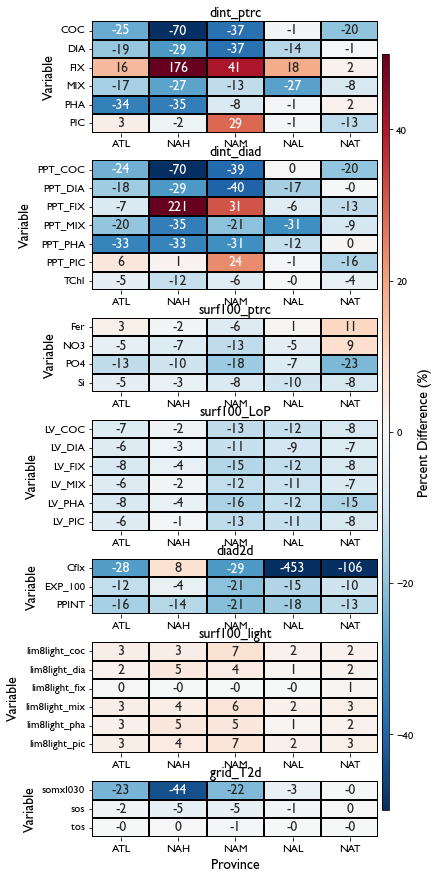

In [64]:
df = compare_runs(datasets, base_run='LA50', diff_run='LAH3')
fig = plot_comparison(df, vmin=-50, vmax=50)

In [66]:
# fp = [
#             'dint_ptrc', 'dint_diad', 'surf100_ptrc', 'surf200_ptrc',
#             'surf200_LoP', 'surf100_LoP', 'surf200_light', 'surf100_light','diad2d', 'grid_T2d'
#         ]

# fp = ['grid_T2d']

# fd = {'grid_T2d': 'physics variables'}

# df = compare_runs(datasets, base_run='LA50', diff_run='LAH3', \
#                   file_patterns = fp , pattern_descriptions = fd)
# fig = plot_comparison(df, vmin=-50, vmax=50, save_path = './plts/COMP-phys.jpg')

# fp = ['diad2d','dint_diad','dint_ptrc']
# fd = {'diad2d': 'carbon flux diagnostics','dint_diad':'assemblage PPT and TChl','dint_ptrc' : 'assemblage'}

# df = compare_runs(datasets, base_run='LA50', diff_run='LAH3', \
#                   file_patterns = fp , pattern_descriptions = fd)
# fig = plot_comparison(df, vmin=-50, vmax=50, save_path = './plts/COMP-eco.jpg')


# fp = ['surf100_ptrc','surf100_LoP','surf100_light']
# fd = {'surf100_ptrc': 'nutrients top 100m',\
#       'surf100_LoP':'nut lim top 100m (blue == more limited)',\
#       'surf100_light' : 'light lim top 100m (blue == more limited)'}

# df = compare_runs(datasets, base_run='LA50', diff_run='LAH3', \
#                   file_patterns = fp , pattern_descriptions = fd)
# fig = plot_comparison(df, vmin=-50, vmax=50, save_path = './plts/COMP-lim100m.jpg')

# fp = ['surf200_ptrc','surf200_LoP','surf200_light']
# fd = {'surf200_ptrc': 'nutrients top 200m',\
#       'surf200_LoP':'nut lim top 200m (blue == more limited)',\
#       'surf200_light' : 'light lim top 200m (blue == more limited)'}

# df = compare_runs(datasets, base_run='LA50', diff_run='LAH3', \
#                   file_patterns = fp , pattern_descriptions = fd)
# fig = plot_comparison(df, vmin=-50, vmax=50, save_path = './plts/COMP-lim200m.jpg')

## regional comparisons - global regions

In [74]:
LA50_dint_ptrc_reg = ut.compute_regional_averages(LA50_dint_ptrc, mask, ['DIA','MIX','COC','PHA','FIX','PIC'])

In [82]:
LA50_dint_ptrc

<xarray.Dataset>
Dimensions:   (province: 5)
Coordinates:
  * province  (province) object 'ATL' 'NAH' 'NAM' 'NAL' 'NAT'
Data variables:
    Si        (province) float64 dask.array<chunksize=(5,), meta=np.ndarray>
    Fer       (province) float64 dask.array<chunksize=(5,), meta=np.ndarray>
    NO3       (province) float64 dask.array<chunksize=(5,), meta=np.ndarray>
    PO4       (province) float64 dask.array<chunksize=(5,), meta=np.ndarray>

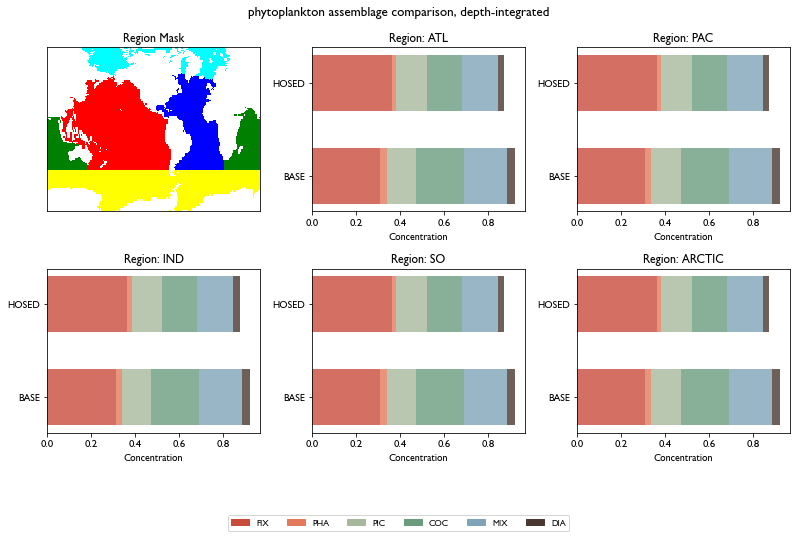

In [84]:
reload(ut)

LA50_dint_ptrc_reg = ut.compute_regional_averages(LA50_dint_ptrc, mask, ['DIA','MIX','COC','PHA','FIX','PIC'])
LAH3_dint_ptrc_reg = ut.compute_regional_averages(LAH3_dint_ptrc, mask, ['DIA','MIX','COC','PHA','FIX','PIC'])

fig, axes = ut.plot_regional_comparison(
    LA50_dint_ptrc_reg, 
    LAH3_dint_ptrc_reg, 
    mask,
    variables=['FIX', 'PHA', 'PIC', 'COC', 'MIX', 'DIA'],
    stit = 'phytoplankton assemblage comparison, depth-integrated', savenam = 'LA50-LAH3_phyto.jpg',\
    colors = kostelec_6,
    dsnams = ['BASE','HOSED'],
    save = True)

plt.show()

# # 'MAC', 'GEL', 'MES', 'PTE', 'PRO', 'BAC'
# fig, axes = plot_regional_comparison(
#     TJ_LA50_avg, 
#     RY_ERA3_avg, 
#     mask,
#     variables=['MAC', 'GEL', 'MES', 'PTE', 'PRO', 'BAC'],
#     stit = 'zooplankton assemblage comparison, top 200 m', savenam = 'RY_ERA3_vs_TJ_LA50_zoo.jpg',\
#     colors = ceskyraj_6,
#     save = True)

# plt.show()

## why LoP -- 

    probably because inf needs to be nan

In [ ]:
w2 = xr.open_dataset('./data/TOM12_TJ_LA50_1944_surf200_LoP.nc')

In [ ]:
plt.pcolormesh(w2.LV_DIA[0,:,:])

print(w2.LV_DIA[0,18,18])


# print(w.LV_DIA[0,:,18,18])